In [34]:
# Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

In [18]:
games = pd.read_csv("../data/processed/game_lifecycle_classified.csv")

games

,app_id,title,launch_price,reviews_total,review_score,tags,baseline_players,relative_6m,relative_12m,relative_24m,lifecycle_category
0,10,Counter-Strike,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",32222.520000,0.936222,0.633616,0.560820,Sustained
1,20,Team Fortress Classic,4.99,5475,0.85,"Action, FPS, Multiplayer, Classic, Hero Shoote...",91.676667,0.886740,0.748027,0.702214,Sustained
2,30,Day of Defeat,4.99,3692,0.87,"FPS, World War II, Multiplayer, Shooter, Actio...",308.633333,0.992623,0.679015,0.624355,Sustained
3,40,Deathmatch Classic,4.99,1923,0.80,"Action, FPS, Classic, Multiplayer, Shooter, Fi...",7.426667,0.828546,0.583932,0.425494,Declining
4,50,Half-Life: Opposing Force,4.99,15498,0.95,"FPS, Action, Classic, Sci fi, Singleplayer, Sh...",63.696667,0.664556,0.632268,0.774295,Sustained
...,...,...,...,...,...,...,...,...,...,...,...
2793,800620,Fallen Hero: Rebirth,6.99,334,0.97,"RPG, Indie, Adventure, Text Based, Choose Your...",8.690000,0.335251,0.532029,0.563483,Sustained
2794,801260,NOSTALGIC TRAIN,18.99,165,0.77,"Indie, Walking Simulator, Atmospheric, Open Wo...",7.243333,0.074551,0.064887,0.147262,Declining
2795,801480,Agent A: A puzzle in disguise,19.99,3864,0.95,"Logic, Point & Click, Hidden Object, Explorati...",11.000000,1.117879,0.742121,1.367879,Growing
2796,801550,VAIL VR,19.99,694,0.76,"Early Access, VR, Shooter, Action, FPS, Multip...",59.756667,0.662018,0.280136,0.299381,Declining


In [19]:
# Create multiplayer column
games["is_multiplayer"] = (games["tags"].str.contains("Multiplayer", case=False, na=False).astype(int))

games

,app_id,title,launch_price,reviews_total,review_score,tags,baseline_players,relative_6m,relative_12m,relative_24m,lifecycle_category,is_multiplayer
0,10,Counter-Strike,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",32222.520000,0.936222,0.633616,0.560820,Sustained,1
1,20,Team Fortress Classic,4.99,5475,0.85,"Action, FPS, Multiplayer, Classic, Hero Shoote...",91.676667,0.886740,0.748027,0.702214,Sustained,1
2,30,Day of Defeat,4.99,3692,0.87,"FPS, World War II, Multiplayer, Shooter, Actio...",308.633333,0.992623,0.679015,0.624355,Sustained,1
3,40,Deathmatch Classic,4.99,1923,0.80,"Action, FPS, Classic, Multiplayer, Shooter, Fi...",7.426667,0.828546,0.583932,0.425494,Declining,1
4,50,Half-Life: Opposing Force,4.99,15498,0.95,"FPS, Action, Classic, Sci fi, Singleplayer, Sh...",63.696667,0.664556,0.632268,0.774295,Sustained,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2793,800620,Fallen Hero: Rebirth,6.99,334,0.97,"RPG, Indie, Adventure, Text Based, Choose Your...",8.690000,0.335251,0.532029,0.563483,Sustained,0
2794,801260,NOSTALGIC TRAIN,18.99,165,0.77,"Indie, Walking Simulator, Atmospheric, Open Wo...",7.243333,0.074551,0.064887,0.147262,Declining,0
2795,801480,Agent A: A puzzle in disguise,19.99,3864,0.95,"Logic, Point & Click, Hidden Object, Explorati...",11.000000,1.117879,0.742121,1.367879,Growing,0
2796,801550,VAIL VR,19.99,694,0.76,"Early Access, VR, Shooter, Action, FPS, Multip...",59.756667,0.662018,0.280136,0.299381,Declining,1


In [20]:
# Compress baseline players as extremely skewed
games["log_baseline_players"] = np.log1p(games["baseline_players"])

In [21]:
# Prediction
features = ["launch_price", "log_baseline_players", "is_multiplayer", "relative_6m"]

X = games[features]
y = games["lifecycle_category"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# Since Declining the largest category, must get baseline accuracy to make sure model beats it and isn't guessing Declining every time
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("Baseline accuracy:", accuracy_score(y_test, dummy_pred))

Baseline accuracy: 0.5107142857142857


In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

In [25]:
y_pred = rf.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest accuracy:", accuracy)

# ACcuracy lower than randomly guessing

Random Forest accuracy: 0.6303571428571428


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Declining       0.77      0.77      0.77       286
     Growing       0.59      0.59      0.59       145
   Sustained       0.36      0.36      0.36       129

    accuracy                           0.63       560
   macro avg       0.57      0.57      0.57       560
weighted avg       0.63      0.63      0.63       560



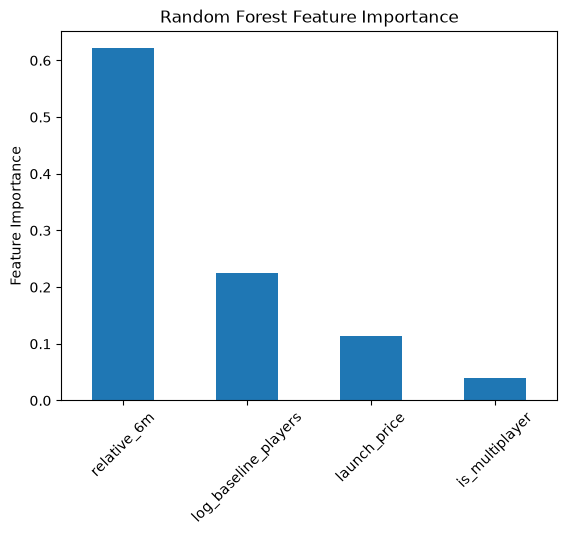

In [ ]:
# Check Feature Importance
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

importance.plot(kind="bar")

plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)

plt.show()

# Early player activity after launch is the strongest predictor of a game’s 24-month lifecycle outcome.

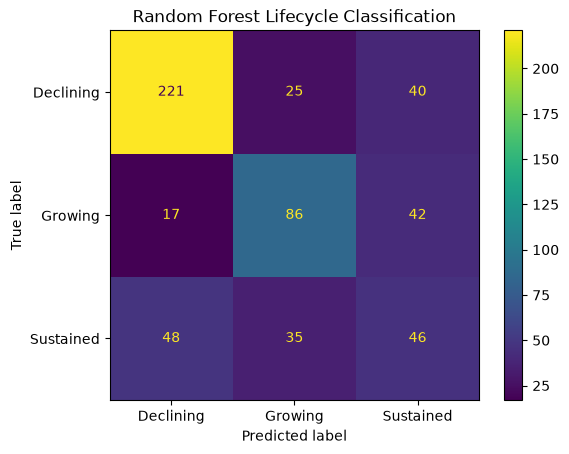

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Random Forest Lifecycle Classification")
plt.show()

# Declining is model's strongest features.

# Growing is ok as it predicted Growing games as Sustained 42 times. That makes sense because a game that eventually grows may look fairly stable during its first six months.

# For Sustained, the model struggles most as it only identifies 46 of 129 sustained games